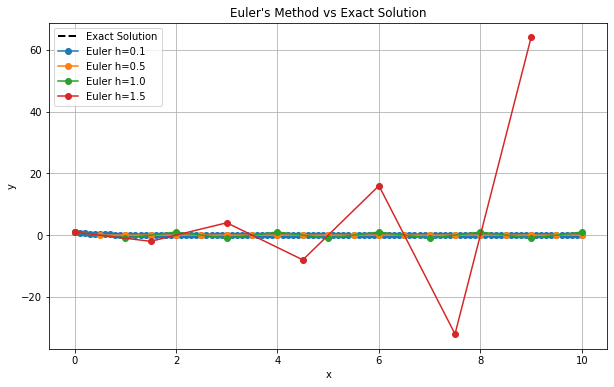

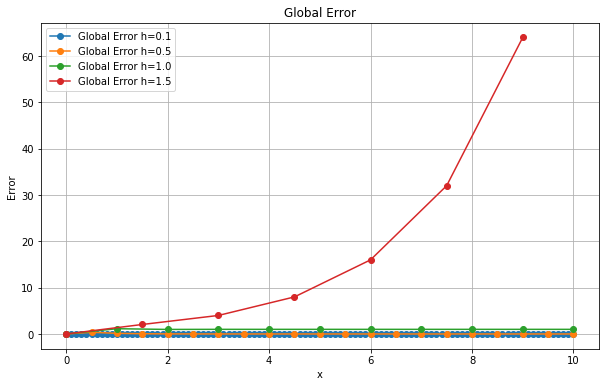

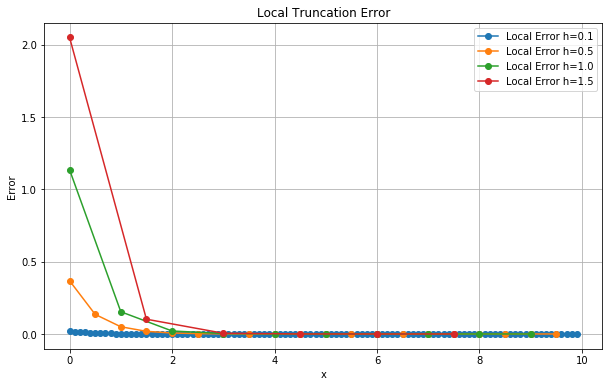

In [13]:
import numpy as np
import matplotlib.pyplot as plt

#differential equation: dy/dx = -2y
def f(x, y):
    return -2 * y

#exact solution for y(0)=1
def exact_solution(x):
    return np.exp(-2 * x)

#euler's method
def euler_method(h, x_start=0, x_end=10, y0=1):
    x_values = np.arange(x_start, x_end + h, h)
    x_values = x_values[x_values <= x_end + 1e-12]

    y_values = np.zeros(len(x_values))
    y_values[0] = y0

    for i in range(len(x_values) - 1):
        step = x_values[i + 1] - x_values[i]
        y_values[i + 1] = y_values[i] + step * f(x_values[i], y_values[i])

    return x_values, y_values

#local truncation error
def local_error(x_values):
    errors = np.zeros(len(x_values) - 1)

    for i in range(len(x_values) - 1):
        x_n = x_values[i]
        step = x_values[i + 1] - x_values[i]

        y_exact_n = exact_solution(x_n)
        y_exact_next = exact_solution(x_values[i + 1])

        y_one_step = y_exact_n + step * f(x_n, y_exact_n)
        errors[i] = abs(y_exact_next - y_one_step)

    return errors

#global error
def global_error(x_values, y_values):
    return np.abs(exact_solution(x_values) - y_values)

step_sizes = [0.1, 0.5, 1.0, 1.5]
results = []

for h in step_sizes:
    x_vals, y_vals = euler_method(h)
    l_err = local_error(x_vals)
    g_err = global_error(x_vals, y_vals)
    results.append((h, x_vals, y_vals, l_err, g_err))

#exact vs euler
plt.figure(figsize=(10, 6))
x_exact = np.linspace(0, 10, 500)
plt.plot(x_exact, exact_solution(x_exact), 'k--', linewidth=2, label='Exact Solution')

for h, x_vals, y_vals, _, _ in results:
    plt.plot(x_vals, y_vals, marker='o', label=f"Euler h={h}")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Euler's Method vs Exact Solution")
plt.legend()
plt.grid(True)
plt.show()

#global error plot
plt.figure(figsize=(10, 6))
for h, x_vals, _, _, g_err in results:
    plt.plot(x_vals, g_err, marker='o', label=f"Global Error h={h}")

plt.xlabel("x")
plt.ylabel("Error")
plt.title("Global Error")
plt.legend()
plt.grid(True)
plt.show()

#local error plot
plt.figure(figsize=(10, 6))
for h, x_vals, _, l_err, _ in results:
    plt.plot(x_vals[:-1], l_err, marker='o', label=f"Local Error h={h}")

plt.xlabel("x")
plt.ylabel("Error")
plt.title("Local Truncation Error")
plt.legend()
plt.grid(True)
plt.show()